In [1]:
# Description: Plot Figure 6 (Shelf edge sea level and cross-isobath geostrophic velocity - decadal averages)
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy as ctpy
from cmocean.cm import thermal, haline, dense, matter, amp, tarn_r, diff, balance, curl
from xarray import open_dataset
from glob import glob
from gsw import f as fcor

## Define file paths.

In [3]:
def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

head = "../proc/"
d = np.load(head + "isobath_200m.npz")
xi, yi, di = d["xi"], d["yi"], d["di"]
xseg0, yseg0 = np.loadtxt(head + "segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]

# Clip start/end to fit segments.
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

def annotate_segments(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-190):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", fontsize=12, color="k", bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="k", lw=1))

In [4]:
fwoa = head + "alongisob_decadal_WOA23_200m.nc"
fadt = head + "yearly_altimetry_adt_200misob.nc"

rho = open_dataset(fwoa)["rho"] + 1000
adt = open_dataset(fadt)["adt"]
x = adt["x"].values

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


In [5]:
detady = np.gradient(adt.values, axis=1)/np.gradient(x*1e3)
g = 9.81 # [m/s2]
f0 = fcor(adt["lat"].values)
aux = -detady*g/f0
ug0 = adt.copy()
ug0.values = aux.copy()
ug0.name = "ug0"

# Calculate decadal steric height from WOA.
rho0 = 1027.5 # [kg/m3]

dz = -(rho["z"].values[1] - rho["z"].values[0])
rhop = rho - rho0
etas = -rhop.sum(dim="z")*dz/rho0

tl = etas.t.values[2:]    # 1995-on
tr = etas.tend.values[2:] # 1995-on

In [6]:
# Average eta_ADT in the same decades as the WOA fields.
tadt = adt.tl.values
tladt = np.array([])
for ti in tadt:
    l, r = ti.split("-")
    tladt = np.append(tladt, int(l))

adt_decavg = dict()
ug0_decavg = dict()
adt_decstd = dict()
ug0_decstd = dict()
for tli in tl:
    if tli==2015:
        tri = tli + 7 # Ending in 2022
    else:
        tri = tli + 9

    # print(tli, tri)
    ft = np.where(np.logical_and(tladt>=tli, tladt<=tri))[0]
    # print(tladt[ft])
    # print(adt.isel(tl=ft).tl.values)

    adti = adt.isel(tl=ft).mean("tl").values
    ug0i = ug0.isel(tl=ft).mean("tl").values*1e2

    adti_std = adt.isel(tl=ft).std("tl").values
    ug0i_std = ug0.isel(tl=ft).std("tl").values*1e2

    ti_label = str(tli) + "-" + str(tri)
    adt_decavg.update({ti_label:adti}) # '1995-2004', '2005-2014', '2015-2022'
    ug0_decavg.update({ti_label:ug0i})

    adt_decstd.update({ti_label:adti_std}) # '1995-2004', '2005-2014', '2015-2022'
    ug0_decstd.update({ti_label:ug0i_std})

## Estimate linear trends for along-isobath averaged sea level.

In [7]:
# Along-isobath average ADT decadal trends.
adt_decavg_yavg = np.array([])
for k in adt_decavg.keys():
    adt_decavg_yavg = np.append(adt_decavg_yavg, adt_decavg[k].mean())

# fig, ax = plt.subplots()
# ax.plot(adt_decavg_yavg, marker="o")
# plt.show()

deta = (adt_decavg_yavg[-1] - adt_decavg_yavg[0])*1e3 # [mm]
detadt = deta/(2022 - 1995) # [mm/yr]
print("")
print("Mean trend in Along-isobath averaged sea level [1995-2022]")
print("deta/dt = %1.2f mm/yr"%detadt)


# Calculate decadal steric height from WOA.
fwoa = head + "alongisob_decadal_WOA23_200m.nc"

rho = open_dataset(fwoa)["rho"] + 1000
rho0 = 1027.5 # [kg/m3]
dz = -(rho["z"].values[1] - rho["z"].values[0])
rhop = rho - rho0
etas = -rhop.sum(dim="z")*dz/rho0


adt_decavg_yavg_steric = np.array([])
for ti in etas.t.values:
    etais = etas.sel(t=ti)
    adt_decavg_yavg_steric = np.append(adt_decavg_yavg_steric, etais.mean())

detas = (adt_decavg_yavg_steric[-1] - adt_decavg_yavg_steric[-3])*1e3 # [mm], (2015 to 2025) minus (1995 to 2005).
dts = 2022 - 1995
detasdt = detas/dts # [mm/yr]
print("Mean trend in *steric* Along-isobath averaged sea level [1995-2022]")
print("deta/dt = %1.2f mm/yr"%detasdt)


Mean trend in Along-isobath averaged sea level [1995-2022]
deta/dt = 2.21 mm/yr
Mean trend in *steric* Along-isobath averaged sea level [1995-2022]
deta/dt = 0.38 mm/yr


getfattr: Removing leading '/' from absolute path names


## Plot Figure 6.

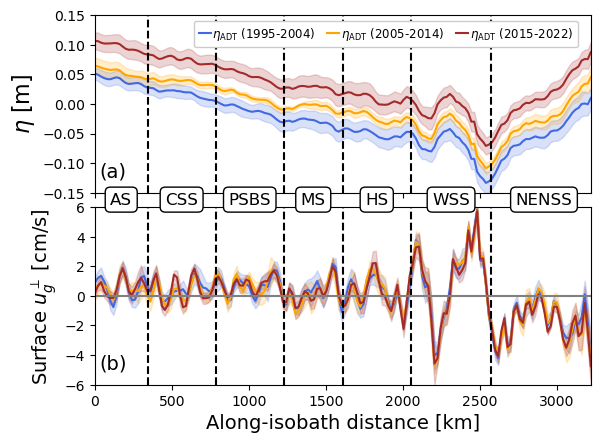

In [8]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
cols = ["royalblue", "orange", "brown"]
for i, ti in enumerate(ug0_decavg.keys()):
    ylo = adt_decavg[ti] - adt_decstd[ti]
    yhi = adt_decavg[ti] + adt_decstd[ti]
    ax1.fill_between(x, ylo, y2=yhi, color=cols[i], alpha=0.2)

    ylo = ug0_decavg[ti] - ug0_decstd[ti]
    yhi = ug0_decavg[ti] + ug0_decstd[ti]
    ax2.fill_between(x, ylo, y2=yhi, color=cols[i], alpha=0.2)

    ti_label = r"$\eta_\text{ADT}$ (%s)"%ti
    ax1.plot(x, adt_decavg[ti], color=cols[i], label=ti_label)
    ax2.plot(x, ug0_decavg[ti], color=cols[i])

ax1.set_ylim(-0.15, 0.15)
ax2.set_ylim(-6, 6)
annotate_segments(ax2, ytxt=6.5)
_ = [ax1.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
_ = [ax2.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
ax1.set_xlim(0, x[-1])
ax1.tick_params(axis='both', direction='out'); ax2.tick_params(axis='both', direction='out')
ax2.axhline(color="gray")
ax1.legend(ncols=3, loc=(0.2, 0.82), framealpha=1, handlelength=1, handletextpad=0.15, columnspacing=1, fontsize=8.5)
ax2.set_xlabel(r"Along-isobath distance [km]", fontsize=14)
ax1.set_ylabel(r"$\eta$ [m]", fontsize=16)
ax2.set_ylabel(r"Surface $u_g^\perp$ [cm/s]", fontsize=14)
ax1.text(0.01, 0.12, "(a)", va="center", fontsize=14, transform=ax1.transAxes)
ax2.text(0.01, 0.12, "(b)", va="center", fontsize=14, transform=ax2.transAxes)
fig.subplots_adjust(hspace=0.08);

In [9]:
fig.savefig("fig6.png", bbox_inches="tight", dpi=200)